## Combine enformer results and bcmpralm results
- plan is to give clear numbers of variants and their origin
- mpralm: 
  - `/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/MPRAlm/results/NGN2_output/mpralm/toptable_mpralm.csv`
- enformer class: 
  - neuro 
    - ultra_rare: `/home/kisa/coding/80K_MPRA/server_results/enformer_results/enformer_class/neuro.ultra-rare_enformer_class.tsv`
    - singleton: `/home/kisa/coding/80K_MPRA/server_results/enformer_results/enformer_class/neuro.singleton_enformer_class.tsv`
- Goal logic:
  - % and absolute number of analyzable sequences (compared to total number of variants + controls put in)
  - % significant => enformer class distribution
  - % positive => % high effect according to enformer
  - % negative => % high effect according to enformer
- idea: combine enformer class files first and combine then mpralm and enformer class (same id)?
  1. combine enformer files: `/home/kisa/coding/80K_MPRA/server_results/enformer_results/enformer_class/merged_enformer_class.tsv`
  2. combine with mpralm table: 
    - add chrom pos ref alt identifier to both tables and merge with this id
  3. Make analysis
  4. Add all controls to MPRAlm
  5. Which sequences have the highest difference

In [19]:
# combine files (enformer class)
# list all files in folder: do it in bash: 

# first=1
# for f in /home/kisa/coding/80K_MPRA/server_results/enformer_results/enformer_class/cava.singleton_enformer_class.tsv /home/kisa/coding/80K_MPRA/server_results/enformer_results/enformer_class/random.ultra-rare_enformer_class.tsv /home/kisa/coding/80K_MPRA/server_results/enformer_results/enformer_class/cardiac.singleton_enformer_class.tsv /home/kisa/coding/80K_MPRA/server_results/enformer_results/enformer_class/neuro.ultra-rare_enformer_class.tsv /home/kisa/coding/80K_MPRA/server_results/enformer_results/enformer_class/neuro.singleton_enformer_class.tsv /home/kisa/coding/80K_MPRA/server_results/enformer_results/enformer_class/cava.ultra-rare_enformer_class.tsv /home/kisa/coding/80K_MPRA/server_results/enformer_results/enformer_class/cardiac.ultra-rare_enformer_class.tsv
# do
#     if [ "$first" ]
#     then
#         cat "$f"
#         first=
#     else
#         cat "$f" | tail -n +2
#     fi
# done > /home/kisa/coding/80K_MPRA/server_results/enformer_results/enformer_class/merged_enformer_class.tsv

# => merged_enformer_class.tsv


#### possible python solution

import os
import pandas as pd
enformer_file_list = os.listdir('/home/kisa/coding/80K_MPRA/server_results/enformer_results/enformer_class')
# add paths: 
enformer_file_list = ['/home/kisa/coding/80K_MPRA/server_results/enformer_results/enformer_class/' + file for file in enformer_file_list if 'merged' not in file]
# check number of rows and sum up
total_number = 0
for file in enformer_file_list:
    df = pd.read_csv(file, sep='\t')
    total_number += df.shape[0]

# check if /home/kisa/coding/80K_MPRA/server_results/enformer_results/enformer_class/merged_enformer_class.tsv has same number of rows
# sanity check number of lines with header?
merged_enformer_class = '/home/kisa/coding/80K_MPRA/server_results/enformer_results/enformer_class/merged_enformer_class.tsv'
merged_enformer_class_df = pd.read_csv(merged_enformer_class, sep='\t')
if total_number != merged_enformer_class_df.shape[0]:
    # throw error number of rows do not match
    raise ValueError('Number of rows do not match')
else:
    print('Santity check passed: merge of enformer class files successful')

Santity check passed: merge of enformer class files successful


In [20]:
import pandas as pd

total_number_of_variants_in_design = 46458

enformer_class_path = '/home/kisa/coding/80K_MPRA/server_results/enformer_results/enformer_class/merged_enformer_class.tsv' 
enformer_class = pd.read_csv(enformer_class_path, sep="\t")
# mpra_result_path = '/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/MPRAlm/results/NGN2_output/mpralm/toptable_mpralm.csv' 
# mpra_result = pd.read_csv(mpra_result_path, sep=",", index_col=0)
mpra_result_path = '/home/kisa/coding/80K_MPRA/server_results/bc_MPRAlm/toptable_GC_Selvarajan_standardNGN2.tsv' 
mpra_result = pd.read_csv(mpra_result_path, sep="\t")
mpra_result

# preprocess mpra_result: remove label on variant_id => ID => merge
mpra_result['ID'] = mpra_result['variant_id'].str.split(':').str[1]

# get total number of cardiac_neuro_cava_random variants in mpra_result
n_tested_vars = mpra_result[mpra_result['variant_id'].str.startswith('cardiac_neuro_cava_random')].shape[0]
n_tested_vars # 41284
# mpra_result.shape[0] # 41464

41284

### Quick questions:
- how many of the MPRAlm results are significant? 
- how many are positive and how many are negative?

In [21]:
mpra_result.head()

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID
0,1.456812,1.860281,16.887425,2.660743e-54,1.103250e-49,111.530180,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...
1,1.606197,0.969005,12.616945,9.251426e-32,1.918006e-27,60.057828,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...
2,1.531276,0.923153,12.197297,3.871885e-30,5.351462e-26,56.506252,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...
3,0.907774,0.994476,11.422970,2.968129e-28,3.076763e-24,53.219004,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...
4,-1.406837,0.849172,-10.628519,8.330598e-24,6.908398e-20,42.509871,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,CYP2D6|ENSG00000100197.23|EH38E3484163|22-4211...


In [22]:
singificants_niveau = 0.1
significant_results = mpra_result[mpra_result['adj.P.Val'] < singificants_niveau]
 

# current dataset: significants niveau: 0.05: 390 => ~0.9% significant
# current dataset: significants niveau: 0.1: 511 => ~1.2% significant
# expected according to Mohan: 5% significant

# number of positive and negative results
pos_effect = significant_results[significant_results['logFC'] > 0]
neg_effect = significant_results[significant_results['logFC'] < 0]

n_significant = significant_results.shape[0]
n_positive = pos_effect.shape[0]
n_negative = neg_effect.shape[0]

print('---------- With a significants niveau of %s:----------'%(singificants_niveau))
print('Number of significant results after bc_MPRAlm: %s'%(significant_results.shape[0]))
print('Fraction of significant results: %s'%(round(n_significant / n_tested_vars, 3)))
print('Number of positive effects: %s'%(n_positive))
print('Number of negative effects: %s'%(n_negative))


---------- With a significants niveau of 0.1:----------
Number of significant results after bc_MPRAlm: 511
Fraction of significant results: 0.012
Number of positive effects: 263
Number of negative effects: 248


#### Add alternative merging possibility with chrom pos ref alt

In [23]:
def get_chrom_pos_ref_alt(ID): 
    """Returns the last part of the ID column (after the last '|')"""
    return ID.split('|')[-1]

In [24]:
# add chrom pos ref alt column
enformer_class['chrom_pos_ref_alt'] = enformer_class['ID'].apply(get_chrom_pos_ref_alt)
# enformer_class['chrom_pos_ref_alt']
mpra_result['chrom_pos_ref_alt'] = mpra_result['variant_id'].apply(get_chrom_pos_ref_alt)
# mpra_result['chrom_pos_ref_alt']

### General summary
- Number of variants we have prioritized with enformer (all non common variants) (32500: missing random singleton set (+2500))
- Number of variants we got from MPRAlm (21102 (older version from march 2024))
- Number of variants we could match 
- Number of variant we could not match
  - old mpralm: 21102: investigate plot AF distribution (Question: how was the AF information added to the MPRAlm plot) => I sampled these myself in `/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/04_MPRAlm/enformer_results/reading_enformer_tsv.ipynb`
  - real data: 41464 tested from bc_MPRAlm; 20541 matchable from enformer class (we have 46458 different variants in total in the design)

In [25]:
print('Number of variants with information from enformer (prioritized (only non common variants)): %s'%(enformer_class.shape[0]))
#! TODO: get numbers of common variants by getting values from design presentation

Number of variants with information from enformer (prioritized (only non common variants)): 32500


In [26]:
# show prioritized from enformer variant number per group:
enformer_class[['ID', 'gene_set', 'variant_type']].rename(columns={'ID': 'variant_number'}).groupby(['gene_set', 'variant_type']).count()

variant_number
gene_set variant_type                
cardiac  singleton               5000
         ultra-rare              5000
cava     singleton               5000
         ultra-rare              5000
neuro    singleton               5000
         ultra-rare              5000
random   ultra-rare              2500

In [27]:
print('Number of variants which were successfully tested with barcode MPRAlm: %s'%(mpra_result.shape[0])) 

Number of variants which were successfully tested with barcode MPRAlm: 41464


In [28]:
matching_column = 'ID'
mpra_enformer_df = mpra_result.merge(enformer_class, on=matching_column, how='left')
mpralm_enformer_matchable = mpra_enformer_df[~mpra_enformer_df['variant_type'].isna()] # 1884 neuro singleton; 8964 all enformer class files
print('The fraction of testable variants in this for this analysis pipeline is: %s'%(round(mpra_enformer_df.shape[0]/total_number_of_variants_in_design,3)))
print('Number of matchable variants between MPRAlm results and enformer class file: %s'%(mpralm_enformer_matchable.shape[0]))
print('The fraction of matchable variants between MPRAlm results and enformer class file: %s'%(round(mpralm_enformer_matchable.shape[0]/mpra_result.shape[0],3)))
print('TODO: with real data: still low number of matchable prioritized variants from enformer class file')
print('TODO: What types of sequences are missing???')
# TODO: investigate with real data if only that few non common variants are in enformer class file
# TODO: what type of sequences are missing?
# get the sequences and number of rows which are not matchable
matched_sequences = mpralm_enformer_matchable[matching_column].to_list()
not_matched_mpralm_results = mpra_result[~mpra_result[matching_column].isin(matched_sequences)]
print('Number of unmatched sequences: %s'%(not_matched_mpralm_results.shape[0]))
not_matched_mpralm_results.head()
# plot the AF distribution of the non matched sequences and mark the median

### old version because old MPRAlm table had AF as column
# import matplotlib.pyplot as plt
# import seaborn as sns
# sns.set_style("whitegrid")
# plt.figure(figsize=(10,6))
# sns.histplot(not_matched_mpralm_results['AF'], bins=50, color='blue')
# plt.axvline(not_matched_mpralm_results['AF'].median(), color='red', linestyle='dashed', linewidth=2)
# plt.title('Allele frequency distribution of non matched sequences')
# plt.xlabel('Allele frequency')
# plt.ylabel('Count')
# plt.show()
# not_matched_mpralm_results['AF'].median() #0.0599
# => many low allele frequency sequences are not in enformer class file
# todo: same with enformer class file not matched


The fraction of testable variants in this for this analysis pipeline is: 0.901
Number of matchable variants between MPRAlm results and enformer class file: 20541
The fraction of matchable variants between MPRAlm results and enformer class file: 0.495
TODO: with real data: still low number of matchable prioritized variants from enformer class file
TODO: What types of sequences are missing???
Number of unmatched sequences: 21312


,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,chrom_pos_ref_alt
1,1.606197,0.969005,12.616945,9.251426e-32,1.918006e-27,60.057828,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,2-219267001-T-C
2,1.531276,0.923153,12.197297,3.871885e-30,5.351462e-26,56.506252,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,5-14259916-C-T
6,1.041370,1.150777,10.155316,1.616258e-22,9.573787e-19,40.137264,cardiac_neuro_cava_random:SLC1A2|ENSG000001104...,SLC1A2|ENSG00000110436.13|EH38E1532674|11-3528...,11-35289966-C-T
8,1.330451,1.082684,9.629536,5.226375e-20,2.407849e-16,33.977775,cardiac_neuro_cava_random:H1-3|ENSG00000124575...,H1-3|ENSG00000124575.7|EH38E3697725|6-26269112...,6-26269112-G-T
9,-1.016115,1.123406,-9.194952,6.216913e-19,2.577781e-15,32.046334,cardiac_neuro_cava_random:DISC1|ENSG0000016294...,DISC1|ENSG00000162946.23|EH38E2873486|1-231734...,1-231734633-A-G


##### Investigate which rows are not matching from the enformer class
- 32500 variants are in the enformer class table
- 23536 are not matchable to the variants in the mpralm table


In [29]:
matched_sequences = mpralm_enformer_matchable[matching_column].to_list()
not_matched_enformer_class = enformer_class[~enformer_class[matching_column].isin(matched_sequences)]
not_matched_enformer_class.shape[0] # 23536 old MPRAlm results; 11959 new results

11959

In [30]:
mpralm_enformer_matchable
mpralm_enformer_matchable['variant_id'].to_list()[0] 

'cardiac_neuro_cava_random:TRIO|ENSG00000038382.23|EH38E2358394|5-14408059-A-G'

### Pos negative variants numbers
- how many of the significant variants can be matched?
- how many positive and negative variants are there in the enformer class table?
- how many of the matched variants which are significant have high effect class of enformer?
- how many of the matched significant effect class have not a high effect class? 
- how many are singleton?
- how many are ultra rare?

In [31]:
mpralm_enformer_matchable

matched_significant_results = mpralm_enformer_matchable[mpralm_enformer_matchable['adj.P.Val'] < singificants_niveau]
 

# current dataset: significants niveau: 0.05: 390 => ~0.9% significant
# current dataset: significants niveau: 0.1: 511 => ~1.2% significant
# expected according to Mohan: 5% significant

# number of positive and negative results
matched_pos_effect = matched_significant_results[matched_significant_results['logFC'] > 0]
matched_neg_effect = matched_significant_results[matched_significant_results['logFC'] < 0]

n_matched_significant = matched_significant_results.shape[0]
n_matched_positive = matched_pos_effect.shape[0]
n_matched_negative = matched_neg_effect.shape[0]
print('---------- With a significants niveau of %s:----------'%(singificants_niveau))
print('Number of significant results after bc_MPRAlm and matching with enformer class file: %s'%(matched_significant_results.shape[0]))
print('Fraction of matchable significant results: %s'%(round(n_matched_significant / n_significant, 3))) 
print('This means %s of the significant results could be matched with enformer class information.\n   Which means if everything works perfect the rest of the signifiant effects is from common variants.'%(round(n_matched_significant / n_significant, 3)))
print('Fraction of significant results: %s'%(round(matched_significant_results.shape[0] / n_tested_vars, 3)))
print('Number of positive effects: %s'%(n_matched_positive))
print('Number of negative effects: %s'%(n_matched_negative))

# significant results enformer class distribution

matched_significant_results[['enformer_class', 'ID']].groupby(['enformer_class' ]).count()



---------- With a significants niveau of 0.1:----------
Number of significant results after bc_MPRAlm and matching with enformer class file: 295
Fraction of matchable significant results: 0.577
This means 0.577 of the significant results could be matched with enformer class information.
   Which means if everything works perfect the rest of the signifiant effects is from common variants.
Fraction of significant results: 0.007
Number of positive effects: 157
Number of negative effects: 138


,ID
enformer_class,
enformer_high,247
enformer_low,21
random,27


In [32]:
mpralm_enformer_matchable[['enformer_class', 'ID']].groupby(['enformer_class']).count()

,ID
enformer_class,
enformer_high,15055
enformer_low,2584
random,2902


In [33]:
significant_high = 247
significant_not_high = 21+27
all_high = 15055
all_not_high = 2584 + 2902
all_values = all_high + all_not_high


total_sig = n_matched_significant
total_non_sig = mpralm_enformer_matchable.shape[0] - n_matched_significant
total_high = all_high
total_non_high = all_not_high
table_total = mpralm_enformer_matchable.shape[0]

# test with chi-square 
from scipy.stats import chisquare
observed = [significant_high, significant_not_high, all_high-significant_high, all_not_high-significant_not_high]
expected = [total_sig * total_high / table_total, total_sig * total_non_high / table_total, total_non_sig * total_high / table_total, total_non_sig * total_non_high / table_total]

chisquare(observed, expected) # Power_divergenceResult(statistic=16.65368095903453, pvalue=0.000832623862389024)
print('interpretation: enformer has a huge number of false positives.')
print('This means the distribution of significant results in the enformer class file is significantly different from the distribution of all results in the enformer class file.')



interpretation: enformer has a huge number of false positives.
This means the distribution of significant results in the enformer class file is significantly different from the distribution of all results in the enformer class file.


### Bin analyse 

In [60]:
logFC_sorted.head()

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,chrom_pos_ref_alt_x,#CHROM,...,ALT,DNase_max,INDEX_max,QUAL,FILTER,INFO,gene_set,variant_type,enformer_class,chrom_pos_ref_alt_y
0,1.456812,1.860281,16.887425,2.660743e-54,1.103250e-49,111.530180,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,5-14408059-A-G,chr5,...,G,496.12640,109_DNASE:fibroblast of,1.0,PASS,AF=6.57117e-06;AC=1,neuro,singleton,enformer_high,5-14408059-A-G
10,1.455633,0.720915,9.351704,6.915400e-19,2.606729e-15,31.228534,cardiac_neuro_cava_random:LMNA|ENSG00000160789...,LMNA|ENSG00000160789.24|EH38E1387716|1-1561528...,1-156152803-G-A,chr1,...,A,452.78010,490_DNASE:HK-2,1.0,PASS,AF=6.57125e-06;AC=1,cava,singleton,enformer_high,1-156152803-G-A
11,1.455633,0.720915,9.351704,6.915400e-19,2.606729e-15,31.228534,cardiac_neuro_cava_random:LMNA|ENSG00000160789...,LMNA|ENSG00000160789.24|EH38E1387716|1-1561528...,1-156152803-G-A,chr1,...,A,452.78010,490_DNASE:HK-2,1.0,PASS,AF=6.57125e-06;AC=1,cardiac,singleton,enformer_high,1-156152803-G-A
32,1.376232,0.664415,7.381958,1.183858e-12,1.636250e-09,17.582675,cardiac_neuro_cava_random:MYBPC3|ENSG000001345...,MYBPC3|ENSG00000134571.12|EH38E2957377|11-4730...,11-47306237-C-G,chr11,...,G,186.52232,551_DNASE:skin fibroblas,1.0,PASS,AF=6.57315e-06;AC=1,cava,singleton,enformer_high,11-47306237-C-G
48,1.361635,1.416795,6.685652,9.861135e-11,8.888742e-08,13.349302,cardiac_neuro_cava_random:DMD|ENSG00000198947....,DMD|ENSG00000198947.18|EH38E3929714|X-31863206...,X-31863206-G-T,chrX,...,T,367.10703,123_DNASE:K562,1.0,PASS,AF=8.90369e-06;AC=1,cardiac,singleton,enformer_high,X-31863206-G-T


In [107]:
# sort by logFC
logFC_sorted = matched_significant_results[['logFC', 'variant_id', 'enformer_class', 'variant_type', 'gene_set', 'DNase_max']].sort_values(by='logFC', ascending=True)

# make equally distant bins of the logFC and plot  number of enformer_high occurences per bin as histogram 
bins = [logFC_sorted.iloc[i*logFC_sorted.shape[0]//10:(i+1)*logFC_sorted.shape[0]//10] for i in range(10)]
# barplot of numbers of enformer_high occurnces in enformer_class column per bin
[bins[i].describe for i in range(10)]
# 495 -0.270634  cardiac_neuro_cava_random:BCL10|ENSG0000014286...   
#  569  0.268013  cardiac_neuro_cava_random:PHACTR1|ENSG00000112...
# This means significant logFC is from -0.27 and from 0.27


[<bound method NDFrame.describe of         logFC                                         variant_id  \
 511 -1.723226  cardiac_neuro_cava_random:GATA5|ENSG0000013070...   
 413 -1.683403  cardiac_neuro_cava_random:AHDC1|ENSG0000012670...   
 23  -1.501145  cardiac_neuro_cava_random:NOS1AP|ENSG000001989...   
 532 -1.481455  cardiac_neuro_cava_random:FBN1|ENSG00000166147...   
 142 -1.476512  cardiac_neuro_cava_random:ECE1|ENSG00000117298...   
 4   -1.406837  cardiac_neuro_cava_random:CYP2D6|ENSG000001001...   
 481 -1.312495  cardiac_neuro_cava_random:GATA5|ENSG0000013070...   
 325 -1.300314  cardiac_neuro_cava_random:SLC6A1|ENSG000001571...   
 178 -1.259631  cardiac_neuro_cava_random:SYNJ1|ENSG0000015908...   
 14  -1.222910  cardiac_neuro_cava_random:LAMA4|ENSG0000011276...   
 12  -1.188018  cardiac_neuro_cava_random:R3HDML|ENSG000001010...   
 42  -1.169550  cardiac_neuro_cava_random:IRF4|ENSG00000137265...   
 445 -1.158859  cardiac_neuro_cava_random:CACNA1C|ENSG00000151...   


In [103]:
# get min max logFC values of bins like: '<bin_min> - <bin_max>' for each bin
bin_description = [str(round(bin['logFC'].min(), 2)) + ' - ' + str(round(bin['logFC'].max(), 2)) for bin in bins]
bin_description

['-1.72 - -0.9',
 '-0.88 - -0.65',
 '-0.64 - -0.5',
 '-0.5 - -0.35',
 '-0.35 - 0.35',
 '0.35 - 0.44',
 '0.45 - 0.58',
 '0.58 - 0.76',
 '0.76 - 0.93',
 '0.94 - 1.46']

Text(0.5, 1.0, 'LogFC distribution of significant results')

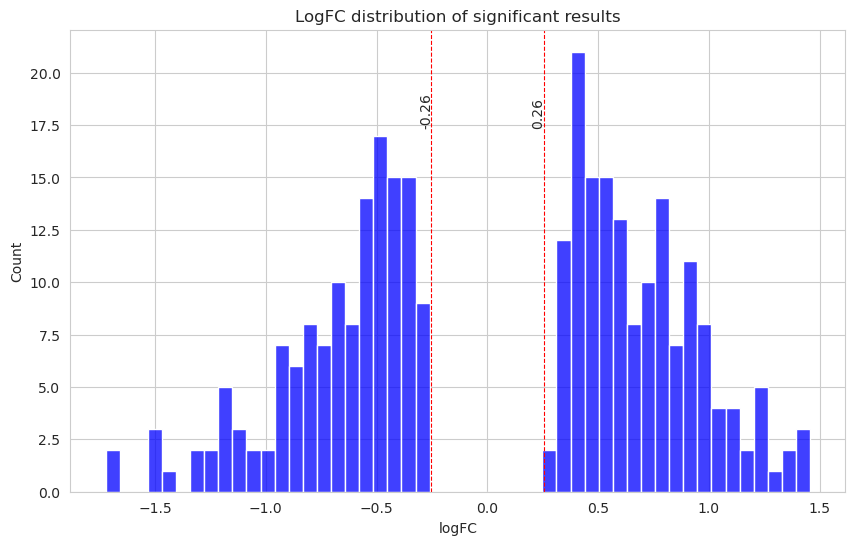

In [154]:
# histogram of logFC distribution
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.figure(figsize=(10,6))
sns.histplot(logFC_sorted['logFC'], bins=50, color='blue')
# make line at 0.26 and -0.26 and annotate
plt.axvline(0.255, color='red', linestyle='dashed', linewidth=0.8)
plt.axvline(-0.255, color='red', linestyle='dashed', linewidth=0.8)
plt.text(0.26-0.06, 17.5, '0.26', rotation=90)
plt.text(-0.26-0.045, 17.5, '-0.26', rotation=90)

# add title 
plt.title('LogFC distribution of significant results')



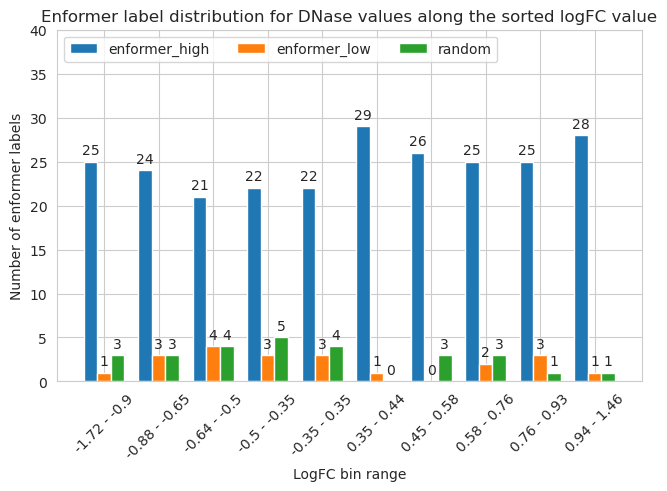

In [156]:
# get the numbers of each group for each bin
number_enformer_high = [bin[bin['enformer_class'] == 'enformer_high'].shape[0] for bin in bins]
number_enformer_low = [bin[bin['enformer_class'] == 'enformer_low'].shape[0] for bin in bins]
number_random = [bin[bin['enformer_class'] == 'random'].shape[0] for bin in bins]
group_numbers = {'enformer_high': number_enformer_high, 'enformer_low': number_enformer_low, 'random': number_random}


# plot number_enformer_low and number_enformer_high in same bar plot 
import matplotlib.pyplot as plt
import numpy as np
x = np.arange(10)  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in group_numbers.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Number of enformer labels')
ax.set_title('Enformer label distribution for DNase values along the sorted logFC value')
ax.set_xticks(x + width, bin_description, rotation=45)
ax.set_xlabel('LogFC bin range')
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 40)

plt.show()


In [101]:
bins

[        logFC                                         variant_id  \
 511 -1.723226  cardiac_neuro_cava_random:GATA5|ENSG0000013070...   
 413 -1.683403  cardiac_neuro_cava_random:AHDC1|ENSG0000012670...   
 23  -1.501145  cardiac_neuro_cava_random:NOS1AP|ENSG000001989...   
 532 -1.481455  cardiac_neuro_cava_random:FBN1|ENSG00000166147...   
 142 -1.476512  cardiac_neuro_cava_random:ECE1|ENSG00000117298...   
 4   -1.406837  cardiac_neuro_cava_random:CYP2D6|ENSG000001001...   
 481 -1.312495  cardiac_neuro_cava_random:GATA5|ENSG0000013070...   
 325 -1.300314  cardiac_neuro_cava_random:SLC6A1|ENSG000001571...   
 178 -1.259631  cardiac_neuro_cava_random:SYNJ1|ENSG0000015908...   
 14  -1.222910  cardiac_neuro_cava_random:LAMA4|ENSG0000011276...   
 12  -1.188018  cardiac_neuro_cava_random:R3HDML|ENSG000001010...   
 42  -1.169550  cardiac_neuro_cava_random:IRF4|ENSG00000137265...   
 445 -1.158859  cardiac_neuro_cava_random:CACNA1C|ENSG00000151...   
 444 -1.158859  cardiac_neuro_cava

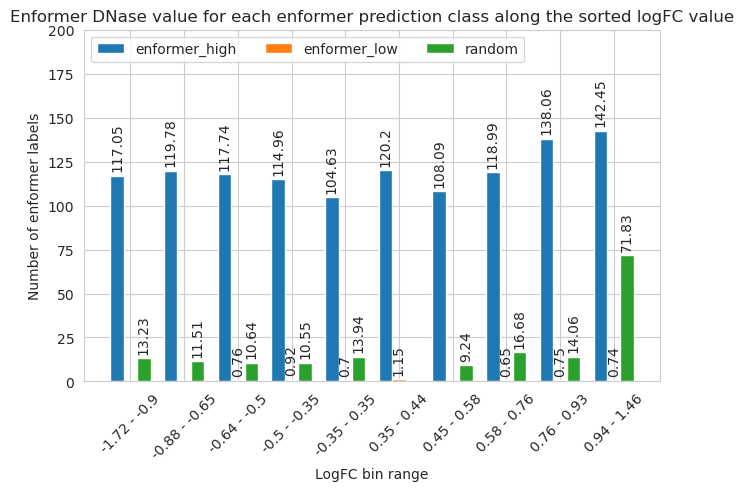

In [158]:
# get for each enformer class the corresponding DNase max value per bin
dnase_max_enformer_high = [round(bin.loc[bin['enformer_class'] == 'enformer_high']['DNase_max'].max(), 2) for bin in bins]
dnase_max_enformer_low = [round(bin.loc[bin['enformer_class'] == 'enformer_low']['DNase_max'].max(), 2) for bin in bins]
dnase_max_random = [round(bin.loc[bin['enformer_class'] == 'random']['DNase_max'].max(), 2) for bin in bins]
dnase_min_enformer_high = [round(bin.loc[bin['enformer_class'] == 'enformer_high']['DNase_max'].min(), 2) for bin in bins]
dnase_min_enformer_low = [round(bin.loc[bin['enformer_class'] == 'enformer_low']['DNase_max'].min(), 2) for bin in bins]
dnase_min_random = [round(bin.loc[bin['enformer_class'] == 'random']['DNase_max'].min(), 2) for bin in bins]
dnase_median_enformer_high = [round(bin.loc[bin['enformer_class'] == 'enformer_high']['DNase_max'].median(), 2) for bin in bins]
dnase_median_enformer_low = [round(bin.loc[bin['enformer_class'] == 'enformer_low']['DNase_max'].median(), 2) for bin in bins]
dnase_median_random = [round(bin.loc[bin['enformer_class'] == 'random']['DNase_max'].median(), 2) for bin in bins]


## not working
# dnase_max_enformer_high = [bin.loc[bin['enformer_class'] == 'enformer_high'].loc['DNase_max'].max() for bin in bins]
# dnase_max_enformer_low = [bin.loc[bin['enformer_class'] == 'enformer_low'].loc['DNase_max'].max() for bin in bins]
# dnase_max_random = [bin.loc[bin['enformer_class'] == 'random'].loc['DNase_max'].max() for bin in bins]
group_dnase_maxs = {'enformer_high': dnase_max_enformer_high, 'enformer_low': dnase_max_enformer_low, 'random': dnase_max_random}
group_dnase_mins = {'enformer_high': dnase_min_enformer_high, 'enformer_low': dnase_min_enformer_low, 'random': dnase_min_random}
group_dnase_medians = {'enformer_high': dnase_median_enformer_high, 'enformer_low': dnase_median_enformer_low, 'random': dnase_median_random}
import matplotlib.pyplot as plt
import numpy as np
x = np.arange(10)  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in group_dnase_mins.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3, rotation=90)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Number of enformer labels')
ax.set_title('Enformer DNase value for each enformer prediction class along the sorted logFC value')
ax.set_xticks(x + width, bin_description, rotation=45)
ax.set_xlabel('LogFC bin range')
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 600) # for dnase_max.median()
ax.set_ylim(0, 200) # for dnase_max.min()
# ax.set_ylim(0, 4300) # for dnase_max.max()

plt.show()

In [ ]:
from scipy.stats import chi2_contingency, chi2, chisquare   
# contingency table
table = [[significant_high, all_high], [significant_not_high, all_not_high]]
stat, p, dof, expected = chi2_contingency(table)
print('dof=%d' % dof)
print(expected)

# interpret test-statistic
prob = 0.95
critical = chi2.ppf(prob, dof)

critical

#### Cell type analysis

In [148]:
matched_significant_results[['gene_set',  'ID']].groupby(['gene_set']).count()

,ID
gene_set,
cardiac,85
cava,90
neuro,101
random,19


#### Advanced analysis with cell-type, variant type and enformer class of the significant results

In [145]:
matched_significant_results[['gene_set', 'variant_type', 'enformer_class', 'ID']].groupby(['gene_set', 'variant_type', 'enformer_class' ]).count()

ID
gene_set variant_type enformer_class    
cardiac  singleton    enformer_high   34
                      enformer_low     4
                      random           7
         ultra-rare   enformer_high   31
                      enformer_low     3
                      random           6
cava     singleton    enformer_high   44
                      enformer_low     7
                      random           1
         ultra-rare   enformer_high   34
                      enformer_low     1
                      random           3
neuro    singleton    enformer_high   39
                      enformer_low     4
                      random           3
         ultra-rare   enformer_high   49
                      enformer_low     2
                      random           4
random   ultra-rare   enformer_high   16
                      random           3

### Supplementary

##### Testing to plot a table from the data while changing the column name: not really working

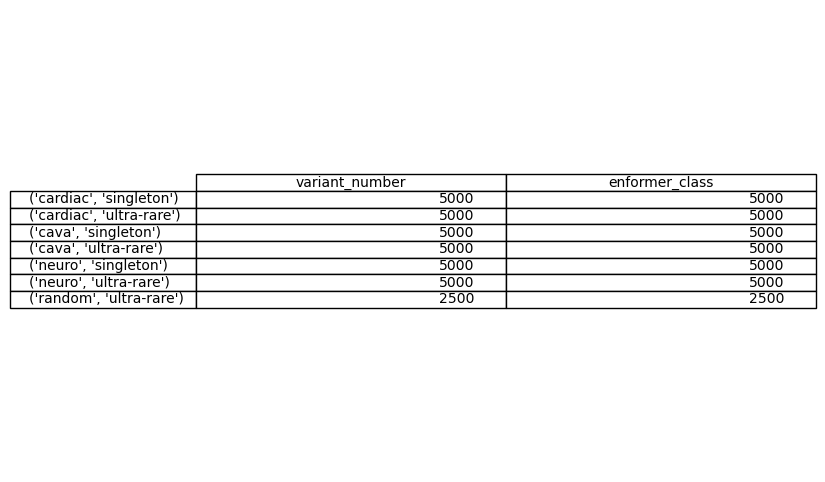

In [34]:
# test: (Does not look good:)
import matplotlib.pyplot as plt
# Group by 'Category' and count values
result = enformer_class[['ID', 'gene_set', 'variant_type', 'enformer_class']].groupby(['gene_set', 'variant_type']).count()

# Rename the column
result = result.rename(columns={'ID': 'variant_number'})

# Plot as a table using matplotlib
plt.figure(figsize=(8, 6))
plt.table(cellText=result.values,
          colLabels=result.columns,
          rowLabels=result.index,
          loc='center')
plt.axis('off')
plt.show()